## Setup

In [1]:
import pandas as pd
import numpy as np
import os
import sys
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
GTE_DIR=os.environ["GTE_DIR"]
from functools import  partial
from glaciation_time_estimator.data_postprocessing.Job_result_fp_generator import generate_tracking_filenames
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
import cmcrameri
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

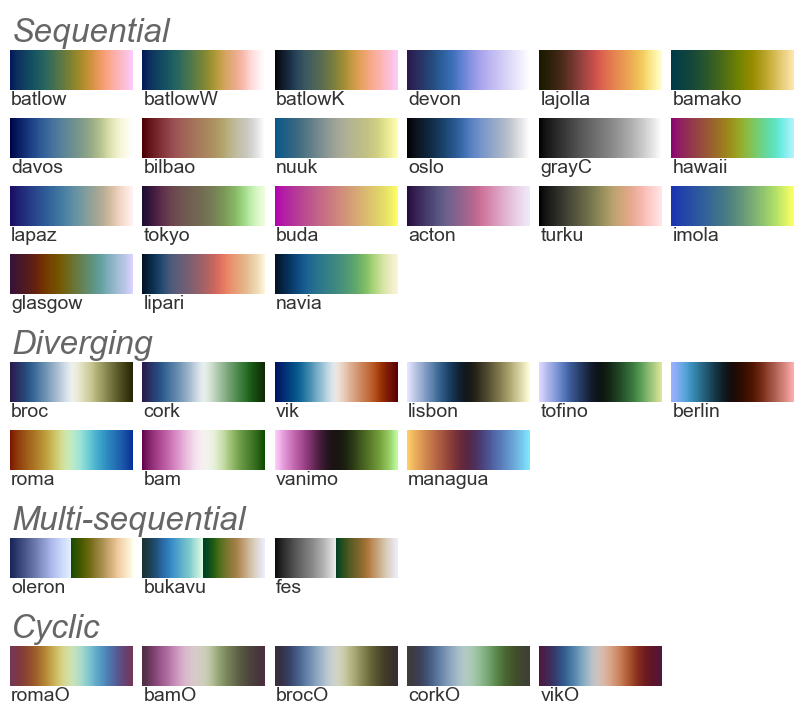

In [17]:
%matplotlib inline
plt.rc('font',family='arial')
plt.rcParams.update({"font.size":6})
font= fm.FontProperties(family='arial')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
cmcrameri.cm.show_cmaps()

In [ ]:
config = read_config(
    os.path.join(GTE_DIR,'configs/2007_tracking/01_01.yaml'))
analyze_year=True
year=2022
global global_rmse
global_rmse = config["Global_sqrt_mse"]
ice_cont_crit_frac = 0.05
# classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]

## Load data

In [2]:
if os.uname()[1]=="n2o":
    combined_cloud_df = pd.read_parquet("/net/n2o/wolke_scratch/dnikolo/Final_results/2009_all.parquet")
if os.uname()[1][:3]=="eu-":
    combined_cloud_df = pd.read_parquet(f"/cluster/work/climate/dnikolo/Cloud_analysis/Final_results/{year}_all.parquet")
combined_cloud_df=combined_cloud_df[~combined_cloud_df.is_large_pix_cloud]
combined_cloud_df = combined_cloud_df[(combined_cloud_df.avg_lat >30) | (combined_cloud_df.avg_lat<-30)]


## Publication figures

### Calculate bar chart data

In [38]:
import xarray as xr


In [39]:
claas_frac_per_type = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/Cloud_cover_by_class/sp/2022_merged_avg.nc")

In [40]:
combined_cloud_df["normalized_area"]=combined_cloud_df["Lifetime [h]"]*combined_cloud_df["avg_size[km]"]
valid_clouds = combined_cloud_df[~combined_cloud_df['Cloud type'].isna()]
T_tot=365*24
total_area_tracked = combined_cloud_df["normalized_area"].sum()/T_tot
cloud_cover = 1.246265e+07+1.452707e+07
print(f"{total_area_tracked:e}")


8.126890e+06


In [41]:
area_per_type = valid_clouds.groupby(["Cloud type"])["normalized_area"].sum()/T_tot
fraction_of_reg_per_type=area_per_type/area_per_type.sum()
fraction_of_reg_per_type*=total_area_tracked/cloud_cover
fraction_of_reg_per_type

Cloud type
Altocumulus        0.006762
Altostratus        0.076012
Cirrostratus       0.004732
Cirrus             0.000301
Cumulus            0.013055
Deep convection    0.005773
Nimbostratus       0.045802
Stratocumulus      0.133466
Stratus            0.015207
Name: normalized_area, dtype: float64

In [42]:
# your original index
orig_idx = claas_frac_per_type_series.index

# 1) define the mapping (no trailing spaces in the keys)
mapping = {
    'time_bnds':   'Time bounds',
    'ci':          'Cirrus',
    'cs':          'Cirrostratus',
    'dc':          'Deep convection',
    'ac':          'Altocumulus',
    'as':          'Altostratus',
    'ns':          'Nimbostratus',
    'cu':          'Cumulus',
    'sc':          'Stratocumulus',
    'st':          'Stratus',
}

# 2a) Strip spaces and rebuild the index via list comprehension
new_idx = [ mapping.get(name.strip(), name.strip())
            for name in orig_idx ]
claas_frac_per_type_series.index = new_idx
claas_frac_per_type_series.index
claas_frac_per_type = claas_frac_per_type_series.drop("Time bounds")
claas_frac_of_reg_per_type = claas_frac_per_type*0.311

In [43]:
frac_tracked = ((fraction_of_reg_per_type)/claas_frac_per_type)
frac_tracked= frac_tracked.to_frame()
frac_tracked = frac_tracked.reset_index(names="Cloud type")
frac_tracked[0]*=100
frac_tracked= frac_tracked.rename({0: "Fraction tracked"},axis=1)

In [44]:
claas_frac_per_type_series = claas_frac_per_type.to_dataframe()#.melt(id_vars=["time_bnds","georef_offset_corrected"])
claas_frac_per_type_series = claas_frac_per_type_series.loc[('2022-07-25 11:52:30', 0, 0.0, 0.0, 0.0)]
idx_list = list(claas_frac_per_type_series.index)
for i in range(len(idx_list)):
    idx_list[i] = idx_list[i].replace("_frac"," ")
claas_frac_per_type_series.index = claas_frac_per_type_series.index.str.replace("_frac", " ")# claas_frac_per_type_df[0]



AttributeError: 'Series' object has no attribute 'to_dataframe'

### Plot combined figure

/tmp/ipykernel_48612/535606456.py:58: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for patch in leg.legendHandles:


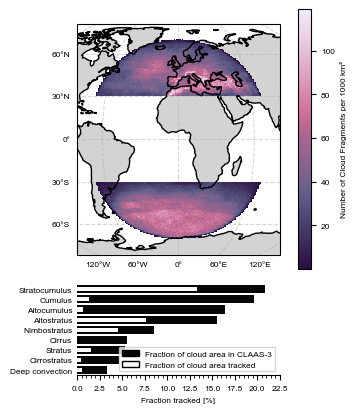

In [48]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(3.46,4.09 ), constrained_layout=True)
gs = gridspec.GridSpec(2, 1,height_ratios=[3,1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[0, 0],projection=ccrs.Robinson(central_longitude=0))


claas_frac_per_type_df = claas_frac_per_type_series.iloc[1:].reset_index(name="Fraction tracked").rename(columns={"index": "Cloud type"}).sort_values(by="Fraction tracked",ascending=False)
claas_frac_per_type_df
# Prepare data
claas_frac_per_type_df.loc[:, "Fraction tracked"] *= 100
# frac_tracked#.loc[:, "Fraction tracked"] *= 100  # Assuming these were also in fraction format (0-1)

# Sort both dataframes by the same order for consistency (optional but recommended)
order = claas_frac_per_type_df.sort_values("Fraction tracked", ascending=False)["Cloud type"]
claas_sorted = claas_frac_per_type_df.set_index("Cloud type").loc[order].reset_index()
frac_sorted = frac_tracked.set_index("Cloud type").loc[order].reset_index()
frac_of_type_tracked = frac_sorted.copy()
frac_of_type_tracked["Fraction tracked"] = frac_sorted["Fraction tracked"]/100 * claas_sorted["Fraction tracked"]/100 *100




# Plot
# fig, ax1 = plt.subplots(figsize=(5.5, 2.5))
sns.barplot(
    data=claas_sorted,
    y="Cloud type",
    x="Fraction tracked",
    ax=ax1,
    palette=cmcrameri.cm.osloS.colors[0:1],
    label="Fraction of cloud area in CLAAS-3"
)

# Overlay bars with smaller width
sns.barplot(
    data=frac_of_type_tracked,
    y="Cloud type",
    x="Fraction tracked",
    ax=ax1,
    color=cmcrameri.cm.osloS.colors[1:2],  # Or another visible color
    # alpha=0.6,
    width=0.4,  # Thinner bars
    label="Fraction of cloud area tracked"
)

# Labels and formatting
ax1.set_xlabel("Fraction tracked [%]")
ax1.set_ylabel("")
# Hide only the tick *marks* (not the labels)
ax1.tick_params(axis='y', which='both', length=0)
ax1.set_xticks(np.linspace(0, 22.5, 10))  # Set x-ticks from 0 to 100 with step of 20
# ax1.set_yticklabels(claas_sorted["Cloud type"],rotation=45)  # Set x-ticks from 0 to 100 with step of 20
ax1.set_xticks(np.arange(0, 45, 1)/2,minor=True)  # Set x-ticks from 0 to 100 with step of 20
ax1.set_xlim(0, 22.5)  # Set x-axis limits from 0 to 100
# ax1.set_title("Fraction of cloud area tracked for each cloud type")
leg = ax1.legend(loc="lower right")
for patch in leg.legendHandles:
    patch.set_edgecolor("black")
    patch.set_linewidth(1.0)
# Remove top and right spines, and left spine line (but keep labels)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)  # Removes only the line, not the ticks or label


######
# MAP
########


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Example DataFrame 'sample' ----
# sample = pd.DataFrame({'avg_lon': [...], 'avg_lat': [...]})
sample=combined_cloud_df
# 1. Define bin edges for 1° increments
lon_bins = np.arange(-80, 82, 1)
lat_bins = np.arange(-80, 82, 1)

# 2. Compute the 2D histogram
heatmap, lon_edges, lat_edges = np.histogram2d(
    sample['avg_lon'],
    sample['avg_lat'],
    bins=[lon_bins, lat_bins]
)

# 3. Mask zero-count cells so they're transparent
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
heatmap /=area_factors
heatmap *=1000
masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

# 4. Set up the figure and Cartopy axes — use Robinson now
# fig = plt.figure(figsize=(3.504, 3.504))
# ax2 = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# Often for Robinson, setting a global extent is a nice choice:
# ax2.set_global()
ax2.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# 5. Add a simple land background (light gray), behind everything
ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# 6. Add lat/lon gridlines *behind* the heatmap
# Note: For certain projections like Robinson, labeling can sometimes be problematic.
gl = ax2.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# 7. Plot the heatmap on top (higher z-order than grid)
mesh = ax2.pcolormesh(
    lon_edges,
    lat_edges,
    masked_heatmap.T,    # transpose to align axes
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap='cmc.acton',
    # cmap='difference_plot_cmap',
    zorder=2
)

# 8. Add coastlines *above* the heatmap
ax2.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# (No country borders added, per your requirement)

# 9. Add colorbar
cbar = plt.colorbar(mesh, ax=ax2, location='right',shrink=0.95)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=6)

fig.savefig(
    os.path.join(GTE_DIR,"Result_graphs","Publication_figures/Database_figure.pdf"),
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)
# ax2.set_title('1° x 1° Area Normalized Heatmap of \nClouds Fragment Number in 2022', fontsize=6,fontweight='bold' )
# plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_combined.png"),dpi=400,bbox_inches='tight')
# plt.savefig(
#     "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Detection_map.pdf",
#     format="pdf",
#     dpi=300
#     # no bbox_inches argument at all
# )
# plt.show()



## Prototyping

In [68]:
combined_cloud_df.groupby(combined_cloud_df["avg_size[km]"]<548265)["normalized_area"].sum()/combined_cloud_df["normalized_area"].sum()

avg_size[km]
False    0.088461
True     0.911539
Name: normalized_area, dtype: float64

In [103]:
area_threshold=16500
small_clouds=combined_cloud_df[combined_cloud_df["avg_size[km]"]<area_threshold]
large_clouds=combined_cloud_df[combined_cloud_df["avg_size[km]"]>=area_threshold]
# 2. Compute the 2D histogram
heatmap, lon_edges, lat_edges = np.histogram2d(
    small_clouds['avg_lon'],
    small_clouds['avg_lat'],
    bins=[lon_bins, lat_bins],
    weights=small_clouds['normalized_area']/T_tot
)

# 3. Mask zero-count cells so they're transparent
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(80,1))* 111*111*4
heatmap /=area_factors

In [100]:
def circular_kernel(radius, normalize=False, dtype=float):
    """
    Create a 2D circular kernel (binary mask) with given radius.

    Parameters
    ----------
    radius : int or float
        Radius of the circle in “pixels” (length units).
        If not integer, the output grid will still be sized by ceil(radius).
    normalize : bool, default False
        If True, divide the kernel by its sum so that sum(kernel)==1.
    dtype : data-type, default float
        Desired data type of the output array.

    Returns
    -------
    kernel : ndarray of shape (2*R+1, 2*R+1)
        Circular mask: ones where x**2 + y**2 <= radius**2, else zeros.
    """
    # Determine grid size
    R = int(np.ceil(radius))
    # Create coordinate grids centered at (0,0)
    y, x = np.ogrid[-R:R+1, -R:R+1]
    # Mask of points inside the circle
    mask = (x**2 + y**2) <= radius**2
    kernel = mask.astype(dtype)
    if normalize:
        kernel /= kernel.sum()
    return kernel
import numpy as np

def fractional_circular_kernel(radius, resolution=50, dtype=float):
    """
    Build a (2R+1)x(2R+1) kernel giving the fraction of each 1×1 pixel
    covered by a circle of given radius centered on the middle pixel.

    Parameters
    ----------
    radius : float
        Radius of the circle in the same “pixel” units.
    resolution : int, optional
        Number of sub‐divisions per side of each pixel (higher → more accurate).
    dtype : data‐type, default float
        Desired output dtype.

    Returns
    -------
    kernel : ndarray, shape (2*ceil(R)+1, 2*ceil(R)+1)
        kernel[i,j] ∈ [0,1] is the fraction of the (i,j)-th pixel
        covered by the circle.
    """
    R = int(np.ceil(radius))
    size = 2*R + 1

    # Coordinates of pixel‐grid centers
    # Pixel (i,j) is centered at (i-R, j-R)
    # Pixel boundaries go from (i-R-0.5,j-R-0.5) to (i-R+0.5,j-R+0.5)

    # Create fine grid for one pixel: subpixel centers in [−0.5, +0.5)
    sub = np.linspace(-0.5 + 0.5/resolution,
                       +0.5 - 0.5/resolution,
                       resolution)
    dy_sub, dx_sub = np.meshgrid(sub, sub, indexing='ij')
    sub_coords = np.stack([dx_sub.ravel(), dy_sub.ravel()], axis=-1)

    kernel = np.empty((size, size), dtype=dtype)
    area_sub = resolution*resolution

    # For each pixel, shift the subpixel grid to the pixel’s position
    for i in range(size):
        for j in range(size):
            # center of this pixel in circle‐center coords
            cx = i - R
            cy = j - R

            # true coordinates of each subpixel sample
            x = cx + sub_coords[:,0]
            y = cy + sub_coords[:,1]

            # count how many lie inside the circle
            inside = (x*x + y*y) <= radius*radius
            kernel[i,j] = inside.sum() / area_sub

    return kernel

# plt.imshow(fractional_circular_kernel(radius=0.5, resolution=3, dtype=float))
# fractional_circular_kernel(radius=0.5, resolution=20, dtype=float)

In [116]:
fractional_circular_kernel(3.3, resolution=3, dtype=float)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.11111111, 0.66666667, 0.66666667,
        0.66666667, 0.11111111, 0.        , 0.        ],
       [0.        , 0.11111111, 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.11111111, 0.        ],
       [0.        , 0.66666667, 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.66666667, 0.        ],
       [0.        , 0.66666667, 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.66666667, 0.        ],
       [0.        , 0.66666667, 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.66666667, 0.        ],
       [0.        , 0.11111111, 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.11111111, 0.        ],
       [0.        , 0.        , 0.11111111, 0.66666667, 0.66666667,
        0.66666667, 0.11111111, 0.        , 0.        ],


In [108]:
short_sample = large_clouds.sample(10000)
radii = np.sqrt(large_clouds["avg_size[km]"] / np.pi) / (
    np.cos(np.deg2rad(large_clouds["avg_lat"])) * 111
)
large_clouds.loc[:,'kernel'] = radii.apply(
    lambda r: fractional_circular_kernel(r, resolution=3, dtype=float)
)

/tmp/ipykernel_48612/1969435974.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  large_clouds.loc[:,'kernel'] = radii.apply(


In [109]:
large_clouds.loc[:,'local_contrib'] = large_clouds.apply(lambda row: row['kernel'] * row['Lifetime [h]']/T_tot, axis=1)


/tmp/ipykernel_48612/3684658400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  large_clouds.loc[:,'local_contrib'] = large_clouds.apply(lambda row: row['kernel'] * row['Lifetime [h]']/T_tot, axis=1)


In [110]:
large_clouds["kernel"]

0          [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
1          [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
2          [[0.0, 0.0, 0.0, 0.1111111111111111, 0.3333333...
3          [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....
4          [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....
                                 ...                        
3905518    [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....
3905583    [[0.0, 0.3333333333333333, 0.0], [0.3333333333...
3905707    [[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.3333333333...
3905807    [[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.3333333333...
3905808    [[0.0, 0.1111111111111111, 0.3333333333333333,...
Name: kernel, Length: 137770, dtype: object

In [111]:
# Assuming you already have:
#   heatmap, lon_edges, lat_edges  # from your small‐cloud histogram
#   short_sample                    # your sampled large_clouds
#   short_sample['local_contrib']   # each is a 2D array of shape (2R+1,2R+1)

for _, row in large_clouds.iterrows():
    kernel = row['local_contrib']         # e.g. shape (m, m), with m = 2*R+1
    lon0, lat0 = row['avg_lon'], row['avg_lat']
    
    # 1. Find the “central” bin indices for this cloud
    i = np.searchsorted(lon_edges, lon0) - 1
    j = np.searchsorted(lat_edges, lat0) - 1
    
    R = kernel.shape[0] // 2   # radius in bins
    
    # 2. Compute slice bounds in the heatmap
    i1, i2 = max(i-R, 0), min(i+R+1, heatmap.shape[0])
    j1, j2 = max(j-R, 0), min(j+R+1, heatmap.shape[1])
    
    # 3. Compute corresponding slice bounds in the kernel
    #    (we clip the kernel if it would run off the edge)
    ki1 = i1 - (i - R)
    ki2 = kernel.shape[0] - ((i + R + 1) - i2)
    kj1 = j1 - (j - R)
    kj2 = kernel.shape[1] - ((j + R + 1) - j2)
    
    # 4. Add in the clipped kernel
    heatmap[i1:i2, j1:j2] += kernel[ki1:ki2, kj1:kj2]

In [118]:
masked_heatmap.mean()

0.371778263462914

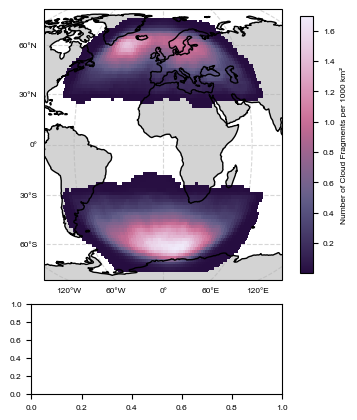

In [113]:
masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)
fig = plt.figure(figsize=(3.46,4.09 ), constrained_layout=True)
gs = gridspec.GridSpec(2, 1,height_ratios=[3,1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[0, 0],projection=ccrs.Robinson(central_longitude=0))
# 4. Set up the figure and Cartopy axes — use Robinson now
# fig = plt.figure(figsize=(3.504, 3.504))
# ax2 = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# Often for Robinson, setting a global extent is a nice choice:
# ax2.set_global()
ax2.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# 5. Add a simple land background (light gray), behind everything
ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# 6. Add lat/lon gridlines *behind* the heatmap
# Note: For certain projections like Robinson, labeling can sometimes be problematic.
gl = ax2.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# 7. Plot the heatmap on top (higher z-order than grid)
mesh = ax2.pcolormesh(
    lon_edges,
    lat_edges,
    masked_heatmap.T,    # transpose to align axes
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap='cmc.acton',
    # cmap='difference_plot_cmap',
    zorder=2
)

# 8. Add coastlines *above* the heatmap
ax2.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# (No country borders added, per your requirement)

# 9. Add colorbar
cbar = plt.colorbar(mesh, ax=ax2, location='right',shrink=0.95)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=6)

In [75]:
np.sqrt(large_clouds["avg_size[km]"]/np.pi)/(np.cos(np.deg2rad(large_clouds["avg_lat"]))*111)-0.5

0          4.989523
1          5.810939
2          4.499487
3          1.831878
4          1.784944
             ...   
3905518    1.924343
3905583    0.308134
3905707    0.785581
3905807    0.703214
3905808    1.386363
Length: 137770, dtype: float64

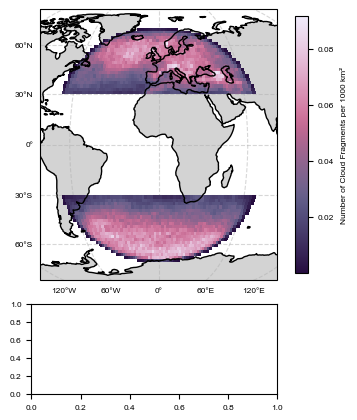

In [69]:
fig = plt.figure(figsize=(3.46,4.09 ), constrained_layout=True)
gs = gridspec.GridSpec(2, 1,height_ratios=[3,1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[0, 0],projection=ccrs.Robinson(central_longitude=0))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Example DataFrame 'sample' ----
# sample = pd.DataFrame({'avg_lon': [...], 'avg_lat': [...]})
sample=combined_cloud_df[combined_cloud_df["avg_size[km]"]<16500]
# 1. Define bin edges for 1° increments
lon_bins = np.arange(-80, 82, 2)
lat_bins = np.arange(-80, 82, 2)

# 2. Compute the 2D histogram
heatmap, lon_edges, lat_edges = np.histogram2d(
    sample['avg_lon'],
    sample['avg_lat'],
    bins=[lon_bins, lat_bins],
    weights=sample['normalized_area']/T_tot
)

# 3. Mask zero-count cells so they're transparent
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(80,1))* 111*111*4
heatmap /=area_factors
# heatmap *=1000
masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

# 4. Set up the figure and Cartopy axes — use Robinson now
# fig = plt.figure(figsize=(3.504, 3.504))
# ax2 = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# Often for Robinson, setting a global extent is a nice choice:
# ax2.set_global()
ax2.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# 5. Add a simple land background (light gray), behind everything
ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# 6. Add lat/lon gridlines *behind* the heatmap
# Note: For certain projections like Robinson, labeling can sometimes be problematic.
gl = ax2.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# 7. Plot the heatmap on top (higher z-order than grid)
mesh = ax2.pcolormesh(
    lon_edges,
    lat_edges,
    masked_heatmap.T,    # transpose to align axes
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap='cmc.acton',
    # cmap='difference_plot_cmap',
    zorder=2
)

# 8. Add coastlines *above* the heatmap
ax2.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# (No country borders added, per your requirement)

# 9. Add colorbar
cbar = plt.colorbar(mesh, ax=ax2, location='right',shrink=0.95)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=6)


In [49]:
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon
from shapely import affinity
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- your DataFrame ----
# must have columns ['avg_lon','avg_lat','avg_size'] with avg_size in km²
sample = combined_cloud_df.copy()

# 1. define 1° grid
lon_bins = np.arange(-80, 82, 1)
lat_bins = np.arange(-80, 82, 1)
nlon = len(lon_bins)-1
nlat = len(lat_bins)-1

# 2. precompute each 1°×1° cell polygon
cell_polygons = [
    [
        Polygon([
            (lon_bins[i], lat_bins[j]),
            (lon_bins[i+1], lat_bins[j]),
            (lon_bins[i+1], lat_bins[j+1]),
            (lon_bins[i], lat_bins[j+1])
        ])
        for j in range(nlat)
    ]
    for i in range(nlon)
]

# 3. compute cell‐area in km² (approx)
#    dx ≃ 111 km, dy ≃ 111 km⋅cos(lat)
lat_centers = 0.5*(lat_bins[:-1] + lat_bins[1:])
cell_area = np.tile(
    (111 * (111 * np.cos(np.deg2rad(lat_centers))))[None, :],
    (nlon, 1)
)

# 4. loop fragments, rasterize each as ellipse→add overlap area
area_sum = np.zeros((nlon, nlat))

for _, row in sample.iterrows():
    lon, lat, size_km2 = row['avg_lon'], row['avg_lat'], row['avg_size[km]']
    # radius in km, then to deg lat/lon
    r_km = np.sqrt(size_km2 / np.pi)
    r_deg_lat = r_km / 111.0
    coslat = np.cos(np.deg2rad(lat))
    r_deg_lon = r_km / (111.0 * coslat)

    # 4a. build shapely ellipse (circle buffered in lat, then x‑scaled)
    circ = Point(lon, lat).buffer(r_deg_lat, resolution=32)
    ellipse = affinity.scale(circ, xfact=r_deg_lon/r_deg_lat, yfact=1.0)

    # 4b. bounding‐box → restrict which cells to test
    minx, miny, maxx, maxy = ellipse.bounds
    i0 = max(0, np.searchsorted(lon_bins,  minx) - 1)
    i1 = min(nlon-1, np.searchsorted(lon_bins,  maxx) - 1)
    j0 = max(0, np.searchsorted(lat_bins,  miny) - 1)
    j1 = min(nlat-1, np.searchsorted(lat_bins,  maxy) - 1)

    # 4c. for each candidate cell, add intersect area (deg² → km²)
    for i in range(i0, i1+1):
        for j in range(j0, j1+1):
            cell = cell_polygons[i][j]
            inter = ellipse.intersection(cell)
            if not inter.is_empty:
                # convert deg²→km² at this cell’s latitude
                lat_mid = lat_centers[j]
                conv = 111.0 * (111.0 * np.cos(np.deg2rad(lat_mid)))
                area_sum[i, j] += inter.area * conv

# 5. compute fractional cover (0–1), then mask/percent
raw_frac = area_sum / cell_area
cloud_frac = np.minimum(raw_frac, 1.0)          # clip >100 %
cloud_pct  = np.ma.masked_where(cloud_frac==0, cloud_frac) * 100

# 6. plot exactly as before—just swap in cloud_pct
fig = plt.figure(figsize=(3.504, 3.504))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
ax.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

gl = ax.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False; gl.right_labels = False

mesh = ax.pcolormesh(
    lon_bins, lat_bins,
    cloud_pct.T,
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap='cmc.acton',
    zorder=2
)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.95)
cbar.set_label('Cloud Cover (%)', fontsize=6)

plt.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/cloud_cover_map.png",
    format="png", dpi=300
)
plt.show()


KeyboardInterrupt: 

In [4]:
# mpl.use('cairo')
plt.close('all')

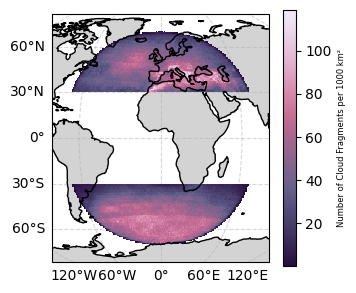

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Example DataFrame 'sample' ----
# sample = pd.DataFrame({'avg_lon': [...], 'avg_lat': [...]})
sample=combined_cloud_df
# 1. Define bin edges for 1° increments
lon_bins = np.arange(-80, 82, 1)
lat_bins = np.arange(-80, 82, 1)

# 2. Compute the 2D histogram
heatmap, lon_edges, lat_edges = np.histogram2d(
    sample['avg_lon'],
    sample['avg_lat'],
    bins=[lon_bins, lat_bins]
)

# 3. Mask zero-count cells so they're transparent
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
heatmap /=area_factors
heatmap *=1000
masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

# 4. Set up the figure and Cartopy axes — use Robinson now
fig = plt.figure(figsize=(3.504, 3.504))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# Often for Robinson, setting a global extent is a nice choice:
# ax.set_global()
ax.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# 5. Add a simple land background (light gray), behind everything
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# 6. Add lat/lon gridlines *behind* the heatmap
# Note: For certain projections like Robinson, labeling can sometimes be problematic.
gl = ax.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# 7. Plot the heatmap on top (higher z-order than grid)
mesh = ax.pcolormesh(
    lon_edges,
    lat_edges,
    masked_heatmap.T,    # transpose to align axes
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap='cmc.acton',
    # cmap='difference_plot_cmap',
    zorder=2
)

# 8. Add coastlines *above* the heatmap
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# (No country borders added, per your requirement)

# 9. Add colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical',shrink=0.95)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=6)

# ax.set_title('1° x 1° Area Normalized Heatmap of \nClouds Fragment Number in 2022', fontsize=6,fontweight='bold' )
# plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_combined.png"),dpi=400,bbox_inches='tight')
plt.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Detection_map.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)
plt.show()


In [6]:
from  matplotlib.colors import LinearSegmentedColormap
# Total number of colors
n_colors = 256

# Define custom sections
yellow_to_red_fraction = 0.35  # Yellow-to-red ends at 4°C
bordeaux_to_purple_fraction = 0.35  # Bordeaux-to-purple starts at 4°C and ends at 6°C
purple_to_pink_fraction = 0.3  # Purple-to-pink for the highest extremes (6°C to 8°C)

# Create an empty array for the colormap
colors = np.zeros((n_colors, 4))  # RGBA array, initialized with zeros

# Define yellow-to-red section (normalized 0 to 4°C)
yellow_to_red_end = int(yellow_to_red_fraction * n_colors)
for i in range(0, yellow_to_red_end):
    t = i / yellow_to_red_end
    colors[i, :3] = (1 - t) * np.array([1, 1, 0.8]) + t * np.array([1, 0.5, 0.2])  # Adjusted yellow to red gradient
    colors[i, 3] = 1  # Set alpha channel to fully opaque

# Define red-to-bordeaux-to-purple section (normalized 4 to 6°C)
bordeaux_to_purple_start = yellow_to_red_end
bordeaux_to_purple_end = bordeaux_to_purple_start + int(bordeaux_to_purple_fraction * n_colors)
for i in range(bordeaux_to_purple_start, bordeaux_to_purple_end):
    t = (i - bordeaux_to_purple_start) / (bordeaux_to_purple_end - bordeaux_to_purple_start)
    colors[i, :3] = (1 - t) * np.array([1, 0.5, 0.2]) + t * np.array([0.5, 0, 0.5])  # Red to purple
    colors[i, 3] = 1  # Set alpha channel to fully opaque

# Define purple-to-pink section (normalized 6 to 8°C)
purple_to_pink_start = bordeaux_to_purple_end
for i in range(purple_to_pink_start, n_colors):
    t = (i - purple_to_pink_start) / (n_colors - purple_to_pink_start)
    colors[i, :3] = (1 - t) * np.array([0.5, 0, 0.5]) + t * np.array([1, 0.75, 0.8])  # Purple to pink
    colors[i, 3] = 1  # Set alpha channel to fully opaque

# Create the custom colormap
difference_plot_cmap = LinearSegmentedColormap.from_list("difference_plot_cmap", colors)

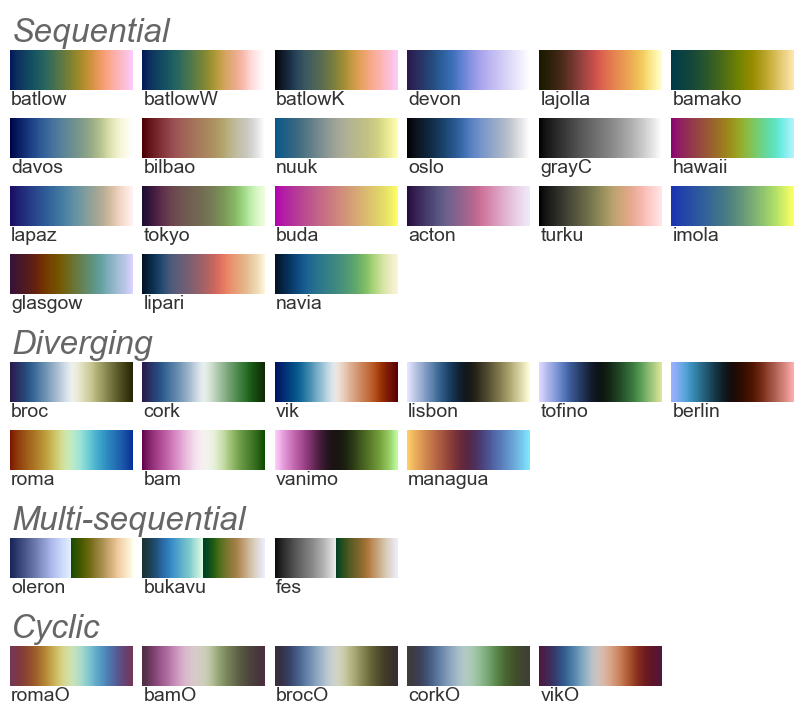

In [28]:
cmcrameri.cm.show_cmaps()

In [29]:
claas_frac_per_type

Cirrus             0.055531
Cirrostratus       0.047085
Deep convection    0.033098
Altocumulus        0.164555
Altostratus        0.155849
Nimbostratus       0.085113
Cumulus            0.196457
Stratocumulus      0.208601
Stratus            0.053067
Name: (2022-07-25 11:52:30, 0, 0.0, 0.0, 0.0), dtype: object

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# assume you have two pandas Series (or columns of a DataFrame) indexed by “Cloud type”:
full_frac  = claast_frac_per_type_series["Fraction tracked"]
reg_frac   = fraction_of_reg_per_type["Fraction tracked"]
#   types      = list of cloud‐type names, in the order you want them plotted

# for demo purposes let me make some dummy data:
types = frac_tracked["Cloud type"].unique()
# full_frac = np.array([85, 60, 25, 30])    # your claast_frac_per_type values
reg_frac  = np.array([75, 55,  3,  2])    # your fraction_of_reg_per_type values

# positions along the y‐axis
y_pos = np.arange(len(types))

fig, ax = plt.subplots(figsize=(6, 3.5))

# draw the “full” bars
ax.barh(y_pos, full_frac,
        height=0.8,
        color="#2166ac",    # dark blue
        edgecolor="k",
        label="Total cloud‐area fraction")

# draw the “inner” bars on top, with a smaller height
ax.barh(y_pos, reg_frac,
        height=0.8,
        color="#67a9cf",    # lighter blue
        edgecolor="k",
        label="Reg.‐area fraction")

# label the y‐axis with the full cloud‐type names
ax.set_yticks(y_pos)
ax.set_yticklabels(types, fontsize=10)
ax.invert_yaxis()  # highest bar on top

# axes labels & legend
ax.set_xlabel("Fraction tracked [%]")
ax.set_title("Fraction of cloud area tracked per cloud type")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


NameError: name 'claast_frac_per_type_series' is not defined

In [ ]:
# fraction_of_reg_per_type = fraction_of_reg_per_type.reset_index(name="Fraction tracked")

In [ ]:
(frac_tracked["Fraction tracked"]/100*claas_frac_per_type_df["Fraction tracked"]/100).sum()

In [ ]:
# frac_tracked["Fraction tracked"] = frac_tracked["Fraction tracked"]/10000

In [ ]:
frac_tracked

In [ ]:
frac_of_type_tracked

In [ ]:
frac_tracked

In [ ]:
frac_tracked

In [ ]:
frac_tracked.set_index("Cloud type")["Fraction tracked"]/100 * claas_frac_per_type_df.set_index("Cloud type")["Fraction tracked"]/100 *100

In [ ]:
frac_of_type_tracked

In [ ]:
frac_sorted

In [ ]:
cmcrameri.cm.show_cmaps()

/tmp/ipykernel_48612/4253514111.py:51: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for patch in leg.legendHandles:


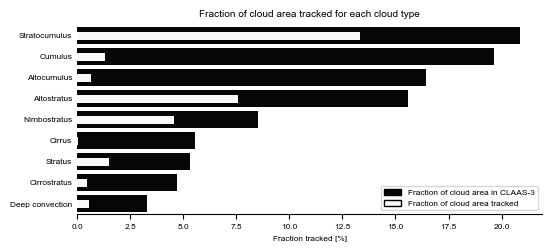

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
claas_frac_per_type_df = claas_frac_per_type_series.iloc[1:].reset_index(name="Fraction tracked").rename(columns={"index": "Cloud type"}).sort_values(by="Fraction tracked",ascending=False)
claas_frac_per_type_df
# Prepare data
claas_frac_per_type_df.loc[:, "Fraction tracked"] *= 100
# frac_tracked#.loc[:, "Fraction tracked"] *= 100  # Assuming these were also in fraction format (0-1)

# Sort both dataframes by the same order for consistency (optional but recommended)
order = claas_frac_per_type_df.sort_values("Fraction tracked", ascending=False)["Cloud type"]
claas_sorted = claas_frac_per_type_df.set_index("Cloud type").loc[order].reset_index()
frac_sorted = frac_tracked.set_index("Cloud type").loc[order].reset_index()
frac_of_type_tracked = frac_sorted.copy()
frac_of_type_tracked["Fraction tracked"] = frac_sorted["Fraction tracked"]/100 * claas_sorted["Fraction tracked"]/100 *100




# Plot
fig, ax = plt.subplots(figsize=(5.5, 2.5))
sns.barplot(
    data=claas_sorted,
    y="Cloud type",
    x="Fraction tracked",
    ax=ax,
    palette=cmcrameri.cm.osloS.colors[0:1],
    label="Fraction of cloud area in CLAAS-3"
)

# Overlay bars with smaller width
sns.barplot(
    data=frac_of_type_tracked,
    y="Cloud type",
    x="Fraction tracked",
    ax=ax,
    color=cmcrameri.cm.osloS.colors[1:2],  # Or another visible color
    # alpha=0.6,
    width=0.4,  # Thinner bars
    label="Fraction of cloud area tracked"
)

# Labels and formatting
ax.set_xlabel("Fraction tracked [%]")
ax.set_ylabel("")
# Hide only the tick *marks* (not the labels)
ax.tick_params(axis='y', which='both', length=0)
ax.set_title("Fraction of cloud area tracked for each cloud type")
leg = ax.legend(loc="lower right")
for patch in leg.legendHandles:
    patch.set_edgecolor("black")
    patch.set_linewidth(1.0)
# Remove top and right spines, and left spine line (but keep labels)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  # Removes only the line, not the ticks or label
fig.tight_layout()

# Save the figure
# fig.savefig(os.path.join(GTE_DIR, "Result_graphs/Publication_figures", "Tracked_fractions_horizontal.pdf"))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Example DataFrame 'sample' ----
# sample = pd.DataFrame({'avg_lon': [...], 'avg_lat': [...]})
sample=combined_cloud_df
# 1. Define bin edges for 1° increments
lon_bins = np.arange(-80, 82, 1)
lat_bins = np.arange(-80, 82, 1)

# 2. Compute the 2D histogram
heatmap, lon_edges, lat_edges = np.histogram2d(
    sample['avg_lon'],
    sample['avg_lat'],
    bins=[lon_bins, lat_bins]
)

# 3. Mask zero-count cells so they're transparent
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
heatmap /=area_factors
heatmap *=1000
masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

# 4. Set up the figure and Cartopy axes — use Robinson now
# fig = plt.figure(figsize=(3.504, 3.504))
# ax2 = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# Often for Robinson, setting a global extent is a nice choice:
# ax2.set_global()
ax2.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# 5. Add a simple land background (light gray), behind everything
ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# 6. Add lat/lon gridlines *behind* the heatmap
# Note: For certain projections like Robinson, labeling can sometimes be problematic.
gl = ax2.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# 7. Plot the heatmap on top (higher z-order than grid)
mesh = ax2.pcolormesh(
    lon_edges,
    lat_edges,
    masked_heatmap.T,    # transpose to align axes
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap='cmc.acton',
    # cmap='difference_plot_cmap',
    zorder=2
)

# 8. Add coastlines *above* the heatmap
ax2.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# (No country borders added, per your requirement)

# 9. Add colorbar
cbar = plt.colorbar(mesh, ax2=ax2, orientation='vertical',shrink=0.95)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=6)

# ax2.set_title('1° x 1° Area Normalized Heatmap of \nClouds Fragment Number in 2022', fontsize=6,fontweight='bold' )
# plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_combined.png"),dpi=400,bbox_inches='tight')
plt.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Detection_map.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(3.5,3))
# claas_frac_per_type_df_sorted = claas_frac_per_type_df.iloc[1:].sort_values(by="Fraction tracked",ascending=False)
claas_frac_per_type_df.loc[:, "Fraction tracked"] *= 100  # Convert to percentage
bar = sns.barplot(data = claas_frac_per_type_df,x="Cloud type",y="Fraction tracked",ax=ax,palette=cmcrameri.cm.batlowS.colors)
ax.set_ylabel("Fraction tracked [%]")
ax.set_title("Faction of cloud area tracked for each cloud type")
# ax.set_xlabel(frac_tracked["Cloud type"],rotation=45)
bar.set_xticklabels(claas_frac_per_type_df["Cloud type"],rotation=45)
fig.tight_layout()
fig.savefig(os.path.join(GTE_DIR,"Result_graphs/Publication_figures","Tracked_fractions.pdf"))